# Corner held-out far-to-near sweep plots

This notebook only reads the saved training-data sweep CSV and regenerates the figures. It does not import TensorFlow and does not train any models.

Run `ml_32_corner_far_to_near.ipynb` first if `data_amount_sweep_corner_far_to_near_fixed_surrogate.csv` does not exist.

The final section adds a paper-style visualization of training-set growth: each training point is colored by the first training percentage at which it enters the far-to-near sweep, using progressively darker green shades.


In [ ]:
from __future__ import annotations

import json
import os
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("/private/tmp") / "matplotlib-cache"))

import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
import pandas as pd

# This notebook can be run either from the transmon experiment folder or from the repo root.
HERE = Path.cwd()
EXPERIMENT_RELATIVE = Path("experiments/model_predict_qubit_TransmonCross_Hamiltonian_params")

if (HERE / "metadata" / "qubit-TransmonCross-Hamiltonian_params.json").exists():
    EXPERIMENT_DIR = HERE
elif (HERE / EXPERIMENT_RELATIVE / "metadata" / "qubit-TransmonCross-Hamiltonian_params.json").exists():
    EXPERIMENT_DIR = HERE / EXPERIMENT_RELATIVE
else:
    raise FileNotFoundError(
        "Could not find the transmon-cross metadata file. "
        "Run this notebook from the repo root or from the transmon experiment folder."
    )

METADATA_DIR = EXPERIMENT_DIR / "metadata"
METADATA_PATH = METADATA_DIR / "qubit-TransmonCross-Hamiltonian_params.json"
VALIDATION_DIR = EXPERIMENT_DIR / "results" / "validation"
ANSYS_SWEEP_DIR = VALIDATION_DIR / "data_amount_sweep_heldout_corner_ansys"
ANSYS_SWEEP_CSV_CANDIDATES = [
    ANSYS_SWEEP_DIR / "heldout_corner_test_predictions_with_ansys_results.csv",
    ANSYS_SWEEP_DIR / "heldout_corner_test_ansys_input_all_fractions.csv",
    ANSYS_SWEEP_DIR / "heldout_corner_test_predictions_all_fractions.csv",
]
ANSYS_SUMMARY_OUT_PATH = ANSYS_SWEEP_DIR / "heldout_corner_test_ansys_error_summary_by_training_percent.csv"
OUT_PATH_CANDIDATES = [
    EXPERIMENT_DIR / "data_amount_sweep_corner_far_to_near_retrained_surrogate.csv",
    EXPERIMENT_DIR / "data_amount_sweep_corner_far_to_near_fixed_surrogate.csv",
]
OUT_PATH = next((path for path in OUT_PATH_CANDIDATES if path.exists()), OUT_PATH_CANDIDATES[0])
SUMMARY_OUT_PATH = OUT_PATH.with_name(OUT_PATH.stem + "_summary.csv")
PLOT_DIR_NAME = "corner_far_to_near_sweep_retrained_surrogate" if "retrained_surrogate" in OUT_PATH.stem else "corner_far_to_near_sweep_fixed_surrogate"
PLOT_DIR = EXPERIMENT_DIR / "plots" / PLOT_DIR_NAME
PLOT_DIR.mkdir(parents=True, exist_ok=True)

if not OUT_PATH.exists():
    raise FileNotFoundError(f"Missing {OUT_PATH}. Run ml_32_corner_far_to_near.ipynb first.")

out = pd.read_csv(OUT_PATH)
FRACTIONS = tuple(sorted(float(v) for v in out["fraction"].dropna().unique()))
if not FRACTIONS:
    raise ValueError("No fractions found in sweep CSV")

REQUESTED_TEST_CORNER_UM = np.array([
    float(out["requested_corner_claw_um"].iloc[0]),
    float(out["requested_corner_ground_um"].iloc[0]),
    float(out["requested_corner_cross_um"].iloc[0]),
])
TEST_FRACTION = 0.15
VAL_FRACTION = 0.15
EPS = 1e-12

GREEN = "#3D8B3D"
GREEN_LIGHT = "#E8F5E8"
ORANGE = "#E87A00"
ORANGE_LIGHT = "#FFF4E6"
PURPLE = "#7B68AE"
PURPLE_LIGHT = "#E8E4F0"
BLUE = "#3F6F8B"
GREY = "#B8B8B8"
DARK = "#222222"

paper_style = {
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10.5,
    "axes.titleweight": "normal",
    "axes.labelsize": 9,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8.0,
    "axes.labelcolor": DARK,
    "axes.edgecolor": "#888888",
    "xtick.color": DARK,
    "ytick.color": DARK,
    "text.color": DARK,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.grid": False,
    "grid.color": "#D7D7D7",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}
COLUMN_WIDTH_IN = 3.35

print(f"Loaded {len(out)} sweep rows from {OUT_PATH}")
print("Fractions:", ", ".join(f"{100*f:.0f}%" for f in FRACTIONS))
print("Plot directory:", PLOT_DIR)
print("Ansys sweep result candidates:")
for candidate in ANSYS_SWEEP_CSV_CANDIDATES:
    print("  ", candidate)


In [10]:
@dataclass
class Scaler:
    min_: np.ndarray
    max_: np.ndarray

    @property
    def range_(self) -> np.ndarray:
        return np.maximum(self.max_ - self.min_, EPS)

    def transform(self, x: np.ndarray) -> np.ndarray:
        return (np.asarray(x, dtype=np.float64) - self.min_) / self.range_


def parse_um(value: object) -> float:
    text = str(value).strip()
    for suffix in ("um", "µm", "μm"):
        if text.endswith(suffix):
            return float(text[: -len(suffix)])
    return float(text)


def load_geometry_um() -> np.ndarray:
    data = json.loads(METADATA_PATH.read_text())
    geometry = []
    for row in data:
        opts = row["design"]["design_options"]
        readout = opts["connection_pads"]["readout"]
        geometry.append([
            parse_um(readout["claw_length"]),
            parse_um(readout["ground_spacing"]),
            parse_um(opts["cross_length"]),
        ])
    return np.asarray(geometry, dtype=np.float64)


def choose_corner_heldout_split(
    geometry_um: np.ndarray,
    requested_corner_um: np.ndarray,
    test_fraction: float = 0.15,
    val_fraction: float = 0.15,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    n_rows = len(geometry_um)
    n_test = int(np.ceil(test_fraction * n_rows))
    n_val = int(np.ceil(val_fraction * n_rows))

    geom_min = geometry_um.min(axis=0)
    geom_max = geometry_um.max(axis=0)
    clipped_corner_um = np.clip(requested_corner_um, geom_min, geom_max)

    corner_scaler = Scaler(geom_min, geom_max)
    geometry_scaled = corner_scaler.transform(geometry_um)
    corner_scaled = corner_scaler.transform(clipped_corner_um.reshape(1, -1))[0]

    corner_distance = np.linalg.norm(geometry_scaled - corner_scaled, axis=1)
    near_corner_order = np.argsort(corner_distance)

    corner_idx = near_corner_order[: n_test + n_val]
    rng = np.random.default_rng(42)
    rng.shuffle(corner_idx)

    test_idx = corner_idx[:n_test]
    val_idx = corner_idx[n_test:]
    train_pool_idx = near_corner_order[n_test + n_val :]
    return train_pool_idx, val_idx, test_idx, clipped_corner_um


def rank_training_far_to_near(geometry_scaled: np.ndarray, train_pool_idx: np.ndarray, test_idx: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    train_geom = geometry_scaled[train_pool_idx]
    test_geom = geometry_scaled[test_idx]
    distances = np.sqrt(((train_geom[:, None, :] - test_geom[None, :, :]) ** 2).sum(axis=2))
    train_to_test_distance = distances.min(axis=1)
    far_to_near_order = np.argsort(-train_to_test_distance)
    return far_to_near_order, train_to_test_distance


def subset_for_fraction(fraction: float) -> np.ndarray:
    n_subset = max(1, int(round(fraction * len(train_pool_idx))))
    subset_local = far_to_near_order[:n_subset]
    return train_pool_idx[subset_local]


def training_entry_percentages() -> np.ndarray:
    entry_percent_local = np.full(len(train_pool_idx), np.nan, dtype=float)
    for fraction in FRACTIONS:
        n_subset = max(1, int(round(fraction * len(train_pool_idx))))
        local_idx = far_to_near_order[:n_subset]
        newly_added = np.isnan(entry_percent_local[local_idx])
        entry_percent_local[local_idx[newly_added]] = fraction * 100.0
    entry_percent_local[np.isnan(entry_percent_local)] = max(FRACTIONS) * 100.0

    entry_percent_global = np.full(len(geom_raw_um), np.nan, dtype=float)
    entry_percent_global[train_pool_idx] = entry_percent_local
    return entry_percent_global


def style_3d_axis(ax):
    ax.view_init(elev=22, azim=-55)
    ax.set_xlabel("claw length (µm)")
    ax.set_ylabel("ground spacing (µm)")
    ax.set_zlabel("cross length (µm)")
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((1, 1, 1, 0))
        axis.pane.set_edgecolor("#DDDDDD")
        axis._axinfo["grid"]["color"] = (0.84, 0.84, 0.84, 0.55)
        axis._axinfo["grid"]["linewidth"] = 0.45


def progression_colormap():
    levels = np.array([fraction * 100.0 for fraction in FRACTIONS], dtype=float)
    colors = plt.get_cmap("Greens")(np.linspace(0.34, 0.88, len(levels)))
    cmap = ListedColormap(colors)
    if len(levels) == 1:
        bounds = np.array([levels[0] - 0.5, levels[0] + 0.5])
    else:
        mids = (levels[:-1] + levels[1:]) / 2.0
        bounds = np.r_[levels[0] - (mids[0] - levels[0]), mids, levels[-1] + (levels[-1] - mids[-1])]
    return levels, cmap, BoundaryNorm(bounds, cmap.N)


geom_raw_um = load_geometry_um()
train_pool_idx, val_idx, test_idx, clipped_corner_um = choose_corner_heldout_split(
    geom_raw_um,
    REQUESTED_TEST_CORNER_UM,
    TEST_FRACTION,
    VAL_FRACTION,
)
geom_split_scaler = Scaler(
    geom_raw_um[train_pool_idx].min(axis=0),
    geom_raw_um[train_pool_idx].max(axis=0),
)
geom_scaled = geom_split_scaler.transform(geom_raw_um)
far_to_near_order, train_to_test_distance = rank_training_far_to_near(geom_scaled, train_pool_idx, test_idx)
entry_percent_global = training_entry_percentages()

print(f"Total samples: {len(geom_raw_um)}")
print(f"Training pool / validation / test: {len(train_pool_idx)} / {len(val_idx)} / {len(test_idx)}")
print("Requested corner [µm]:", REQUESTED_TEST_CORNER_UM)
print("Used clipped corner [µm]:", clipped_corner_um)


Total samples: 1934
Training pool / validation / test: 1352 / 291 / 291
Requested corner [µm]: [ 50.   2. 420.]
Used clipped corner [µm]: [ 70.    4.1 420. ]


In [ ]:
def first_existing_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    return next((col for col in candidates if col in df.columns), None)


def load_ansys_sweep_errors() -> tuple[pd.DataFrame | None, Path | None]:
    for path in ANSYS_SWEEP_CSV_CANDIDATES:
        if not path.exists():
            continue
        df = pd.read_csv(path)
        if df.empty:
            continue

        freq_err_col = first_existing_column(df, ["ansys_frequency_pct_error", "frequency_pct_error"])
        alpha_err_col = first_existing_column(df, ["ansys_anharmonicity_pct_error", "anharmonicity_pct_error", "alpha_pct_error"])
        target_freq_col = first_existing_column(df, ["ref_qubit_frequency_GHz", "target_qubit_frequency_GHz"])
        target_alpha_col = first_existing_column(df, ["ref_anharmonicity_MHz", "target_anharmonicity_MHz"])
        ansys_freq_col = first_existing_column(df, ["ansys_qubit_frequency_GHz", "ansys_pred_qubit_frequency_GHz", "actual_qubit_frequency_GHz", "sim_qubit_frequency_GHz"])
        ansys_alpha_col = first_existing_column(df, ["ansys_anharmonicity_MHz", "ansys_pred_anharmonicity_MHz", "actual_anharmonicity_MHz", "sim_anharmonicity_MHz"])

        work = df.copy()
        if freq_err_col and alpha_err_col and work[[freq_err_col, alpha_err_col]].notna().any().any():
            work["ansys_frequency_pct_error_plot"] = pd.to_numeric(work[freq_err_col], errors="coerce")
            work["ansys_anharmonicity_pct_error_plot"] = pd.to_numeric(work[alpha_err_col], errors="coerce")
        elif target_freq_col and target_alpha_col and ansys_freq_col and ansys_alpha_col:
            target_freq = pd.to_numeric(work[target_freq_col], errors="coerce")
            target_alpha = pd.to_numeric(work[target_alpha_col], errors="coerce")
            ansys_freq = pd.to_numeric(work[ansys_freq_col], errors="coerce")
            ansys_alpha = pd.to_numeric(work[ansys_alpha_col], errors="coerce")
            work["ansys_frequency_pct_error_plot"] = 100.0 * (ansys_freq - target_freq).abs() / np.maximum(target_freq.abs(), EPS)
            work["ansys_anharmonicity_pct_error_plot"] = 100.0 * (ansys_alpha - target_alpha).abs() / np.maximum(target_alpha.abs(), EPS)
        else:
            continue

        required = ["training_percent", "seed", "ansys_frequency_pct_error_plot", "ansys_anharmonicity_pct_error_plot"]
        if not all(col in work.columns for col in required):
            continue
        work = work.dropna(subset=required).copy()
        if work.empty:
            continue

        if "n_samples" not in work.columns:
            n_lookup = out[["training_percent", "seed", "n_samples"]].drop_duplicates()
            work = work.merge(n_lookup, on=["training_percent", "seed"], how="left")
        work["ansys_mean_hamiltonian_pct_error_plot"] = work[
            ["ansys_frequency_pct_error_plot", "ansys_anharmonicity_pct_error_plot"]
        ].mean(axis=1)
        return work, path
    return None, None


ansys_error_df, ansys_error_path = load_ansys_sweep_errors()

if ansys_error_df is not None:
    summary = (
        ansys_error_df.groupby(["training_percent", "n_samples"], as_index=False)
        .agg(
            n_ansys=("ansys_mean_hamiltonian_pct_error_plot", "size"),
            ansys_mean=("ansys_mean_hamiltonian_pct_error_plot", "mean"),
            ansys_std=("ansys_mean_hamiltonian_pct_error_plot", "std"),
            ansys_median=("ansys_mean_hamiltonian_pct_error_plot", "median"),
            ansys_frequency_mean=("ansys_frequency_pct_error_plot", "mean"),
            ansys_alpha_mean=("ansys_anharmonicity_pct_error_plot", "mean"),
        )
        .sort_values("training_percent")
    )
    ANSYS_SUMMARY_OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    summary.to_csv(ANSYS_SUMMARY_OUT_PATH, index=False)

    with plt.rc_context(paper_style):
        fig, ax = plt.subplots(figsize=(COLUMN_WIDTH_IN, 2.45))

        x = summary["training_percent"].to_numpy()
        mean = summary["ansys_mean"].to_numpy()
        std = summary["ansys_std"].fillna(0).to_numpy()
        median = summary["ansys_median"].to_numpy()

        ax.plot(x, mean, marker="o", markersize=3.8, linewidth=1.5, color=GREEN, label="Mean", zorder=3)
        ax.fill_between(x, mean - std, mean + std, color=GREEN_LIGHT, alpha=0.65, linewidth=0, zorder=1)
        ax.plot(x, median, marker="s", markersize=3.2, linewidth=1.0, color=PURPLE, linestyle="--", label="Median", zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels([f"{v:.0f}" for v in x])
        ax.set_xlabel("Training pool used [%]")
        ax.set_ylabel("Ansys Hamiltonian error [%]")
        ax.set_title("Held-out corner Ansys validation")
        ax.grid(axis="y", linestyle=":", color="#D7D7D7")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_ylim(bottom=0)
        ax.margins(x=0.04)
        ax.legend(loc="upper right", frameon=True, edgecolor="#CCCCCC", facecolor="white", handlelength=1.25, borderpad=0.35, labelspacing=0.35)

        fig.tight_layout(pad=0.35)
        for stem in ["corner_far_to_near_learning_curve", "corner_far_to_near_learning_curve_ansys"]:
            fig.savefig(PLOT_DIR / f"{stem}.pdf", bbox_inches="tight", pad_inches=0.03)
            fig.savefig(PLOT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
        plt.show()

    print(f"Loaded Ansys sweep errors from {ansys_error_path}")
    print(f"Wrote Ansys summary to {ANSYS_SUMMARY_OUT_PATH}")
else:
    surrogate_summary = (
        out.groupby(["training_percent", "n_samples"], as_index=False)
        .agg(
            surrogate_test_mean=("test_mean_hamiltonian_pct", "mean"),
            surrogate_test_std=("test_mean_hamiltonian_pct", "std"),
            dist_min=("subset_to_test_nn_distance_min", "mean"),
            dist_median=("subset_to_test_nn_distance_median", "mean"),
            dist_max=("subset_to_test_nn_distance_max", "mean"),
        )
        .sort_values("training_percent")
    )
    summary = surrogate_summary
    print("No completed Ansys sweep CSV found yet, so the Ansys learning-curve plot was skipped.")
    print("Fill ansys_qubit_frequency_GHz and ansys_anharmonicity_MHz in one of:")
    for candidate in ANSYS_SWEEP_CSV_CANDIDATES:
        print("  ", candidate)

summary


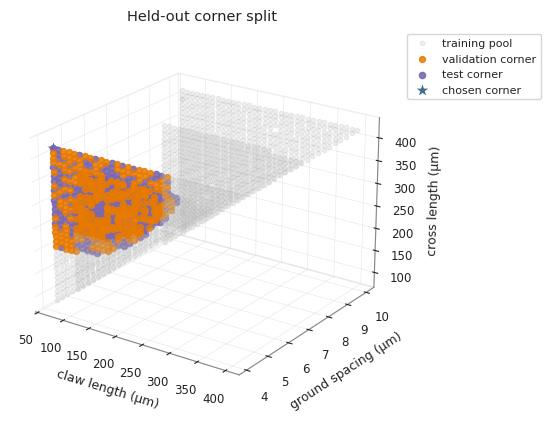

In [12]:
with plt.rc_context(paper_style):
    fig = plt.figure(figsize=(5.4, 4.3))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(geom_raw_um[train_pool_idx, 0], geom_raw_um[train_pool_idx, 1], geom_raw_um[train_pool_idx, 2], s=10, c=GREY, alpha=0.22, label="training pool", depthshade=False)
    ax.scatter(geom_raw_um[val_idx, 0], geom_raw_um[val_idx, 1], geom_raw_um[val_idx, 2], s=18, c=ORANGE, alpha=0.86, label="validation corner", depthshade=False)
    ax.scatter(geom_raw_um[test_idx, 0], geom_raw_um[test_idx, 1], geom_raw_um[test_idx, 2], s=20, c=PURPLE, alpha=0.90, label="test corner", depthshade=False)
    ax.scatter([clipped_corner_um[0]], [clipped_corner_um[1]], [clipped_corner_um[2]], s=130, marker="*", c=BLUE, edgecolor="white", linewidth=0.8, label="chosen corner", depthshade=False)

    style_3d_axis(ax)
    ax.set_title("Held-out corner split")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / "corner_split_3d.pdf", bbox_inches="tight")
    fig.savefig(PLOT_DIR / "corner_split_3d.png", dpi=300, bbox_inches="tight")
    plt.show()


In [13]:
def plot_fraction_3d(fraction: float, save: bool = True) -> None:
    subset_idx = subset_for_fraction(fraction)
    unused_idx = np.setdiff1d(train_pool_idx, subset_idx, assume_unique=False)

    with plt.rc_context(paper_style):
        fig = plt.figure(figsize=(5.6, 4.3))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(geom_raw_um[unused_idx, 0], geom_raw_um[unused_idx, 1], geom_raw_um[unused_idx, 2], s=8, c=GREY, alpha=0.13, label="not used yet", depthshade=False)
        ax.scatter(geom_raw_um[subset_idx, 0], geom_raw_um[subset_idx, 1], geom_raw_um[subset_idx, 2], s=13, c=GREEN, alpha=0.76, label=f"training used ({fraction:.0%})", depthshade=False)
        ax.scatter(geom_raw_um[val_idx, 0], geom_raw_um[val_idx, 1], geom_raw_um[val_idx, 2], s=18, c=ORANGE, alpha=0.86, label="validation corner", depthshade=False)
        ax.scatter(geom_raw_um[test_idx, 0], geom_raw_um[test_idx, 1], geom_raw_um[test_idx, 2], s=20, c=PURPLE, alpha=0.90, label="test corner", depthshade=False)
        ax.scatter([clipped_corner_um[0]], [clipped_corner_um[1]], [clipped_corner_um[2]], s=130, marker="*", c=BLUE, edgecolor="white", linewidth=0.8, label="chosen corner", depthshade=False)

        style_3d_axis(ax)
        ax.set_title(f"Geometry coverage at {fraction:.0%} training fraction")
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)
        fig.tight_layout()

        if save:
            stem = f"geometry_3d_fraction_{int(round(fraction * 100)):03d}pct"
            fig.savefig(PLOT_DIR / f"{stem}.pdf", bbox_inches="tight")
            fig.savefig(PLOT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
        plt.show()


def plot_fraction_pairwise(fraction: float, save: bool = True) -> None:
    subset_idx = subset_for_fraction(fraction)
    unused_idx = np.setdiff1d(train_pool_idx, subset_idx, assume_unique=False)
    pairs = [
        (0, 1, "claw length (µm)", "ground spacing (µm)"),
        (0, 2, "claw length (µm)", "cross length (µm)"),
        (1, 2, "ground spacing (µm)", "cross length (µm)"),
    ]

    with plt.rc_context(paper_style):
        fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.65))
        for ax, (i, j, xlabel, ylabel) in zip(axes, pairs):
            ax.scatter(geom_raw_um[unused_idx, i], geom_raw_um[unused_idx, j], s=8, c=GREY, alpha=0.13, label="not used yet")
            ax.scatter(geom_raw_um[subset_idx, i], geom_raw_um[subset_idx, j], s=12, c=GREEN, alpha=0.76, label="training used")
            ax.scatter(geom_raw_um[val_idx, i], geom_raw_um[val_idx, j], s=16, c=ORANGE, alpha=0.86, label="validation corner")
            ax.scatter(geom_raw_um[test_idx, i], geom_raw_um[test_idx, j], s=18, c=PURPLE, alpha=0.90, label="test corner")
            ax.scatter([clipped_corner_um[i]], [clipped_corner_um[j]], s=95, marker="*", c=BLUE, edgecolor="white", linewidth=0.7, label="chosen corner")
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.grid(linestyle=":", color="#D7D7D7", alpha=0.7)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=5, frameon=True, bbox_to_anchor=(0.5, -0.11))
        fig.suptitle(f"Pairwise geometry coverage at {fraction:.0%} training fraction", y=1.03)
        fig.tight_layout()

        if save:
            stem = f"geometry_pairwise_fraction_{int(round(fraction * 100)):03d}pct"
            fig.savefig(PLOT_DIR / f"{stem}.pdf", bbox_inches="tight")
            fig.savefig(PLOT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
        plt.show()


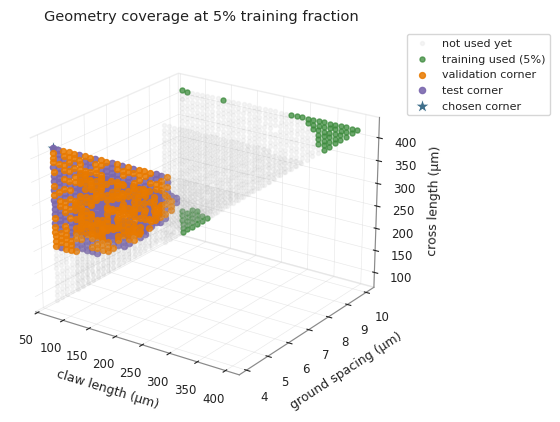

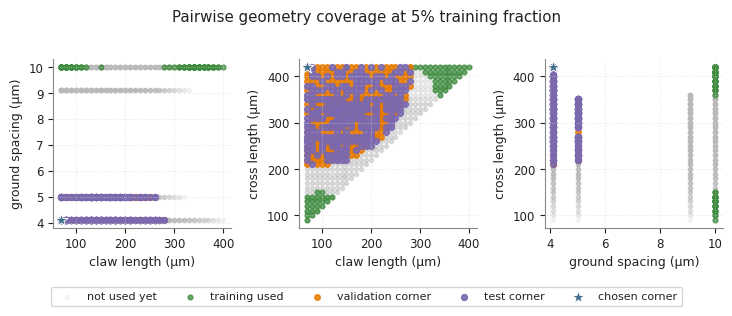

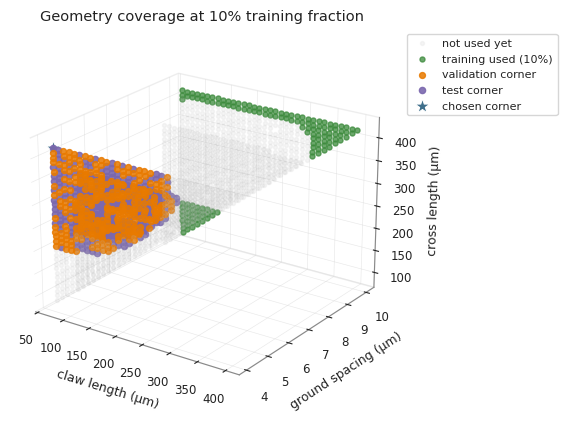

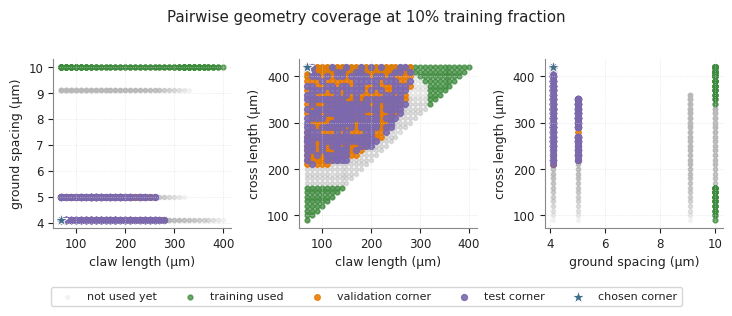

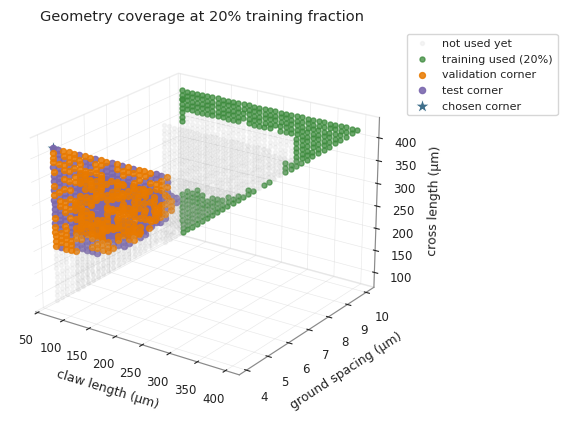

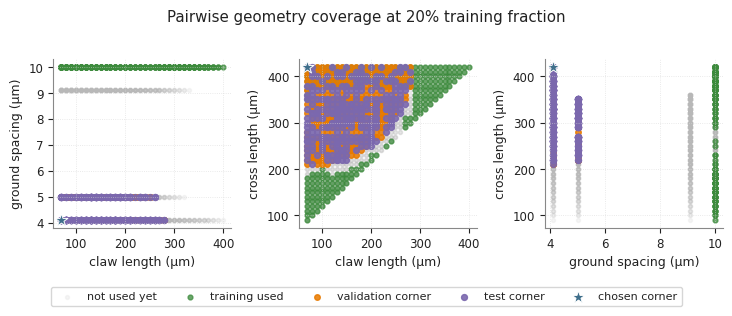

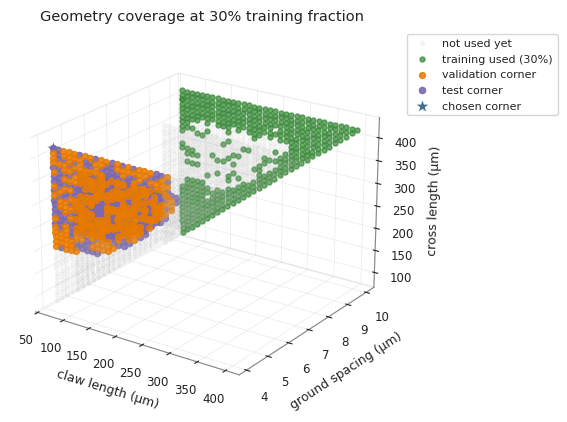

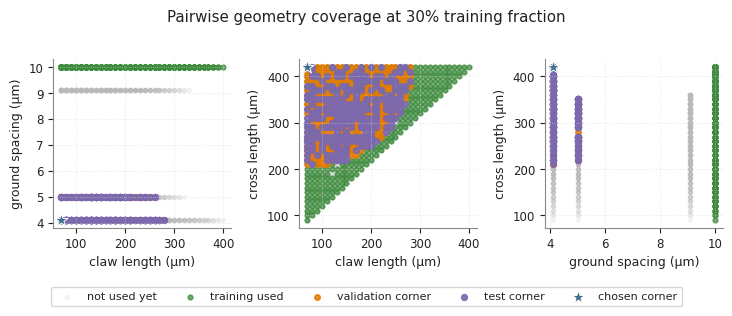

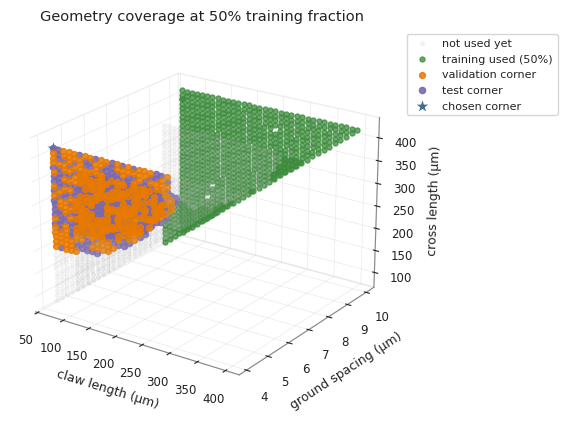

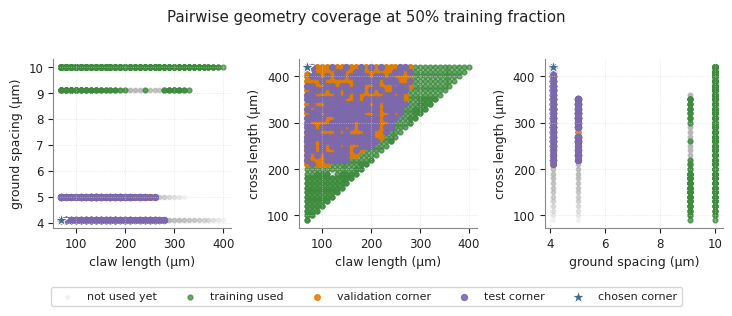

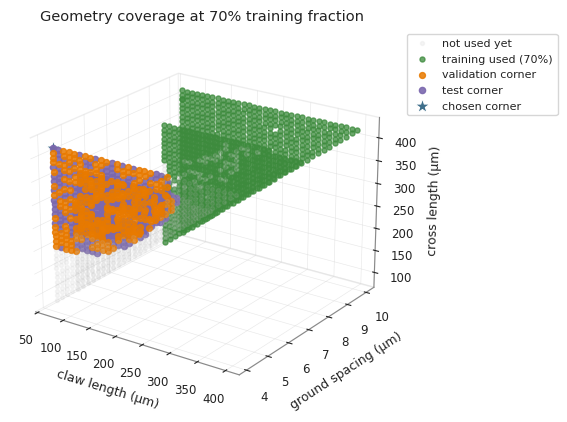

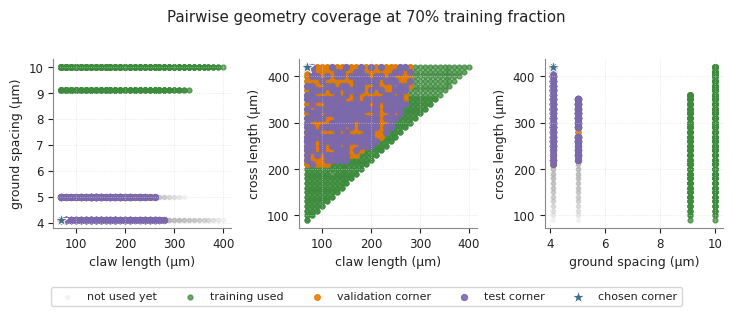

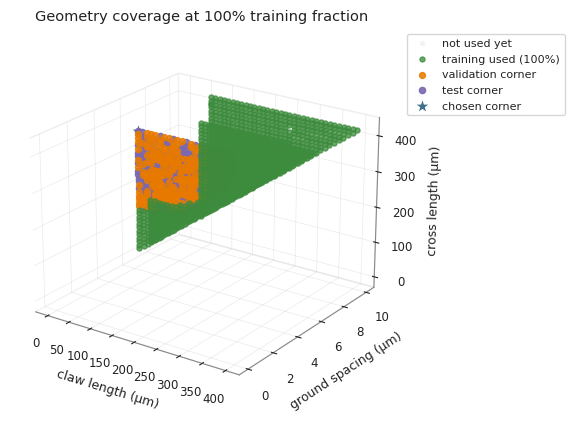

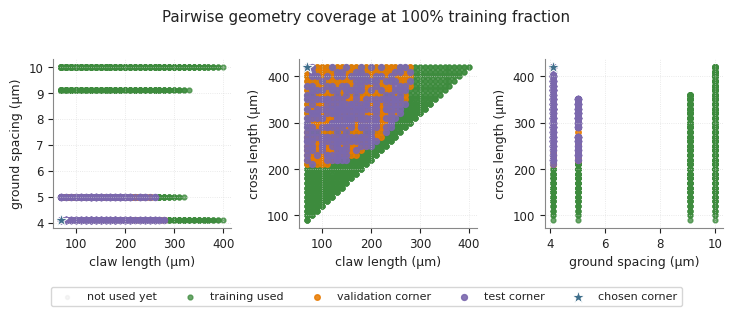

Saved fraction-by-fraction geometry plots to /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots/corner_far_to_near_sweep_fixed_surrogate


In [14]:
for fraction in FRACTIONS:
    plot_fraction_3d(fraction)
    plot_fraction_pairwise(fraction)

print(f"Saved fraction-by-fraction geometry plots to {PLOT_DIR}")


In [ ]:
with plt.rc_context(paper_style):
    n_cols = 5 if len(FRACTIONS) > 8 else 4
    n_rows = int(np.ceil(len(FRACTIONS) / n_cols))
    fig = plt.figure(figsize=(11.0, 5.4 if n_rows <= 2 else 7.4))

    handles = None
    for panel_idx, fraction in enumerate(FRACTIONS, start=1):
        subset_idx = subset_for_fraction(fraction)
        ax = fig.add_subplot(n_rows, n_cols, panel_idx, projection="3d")
        train_pool_handle = ax.scatter(geom_raw_um[train_pool_idx, 0], geom_raw_um[train_pool_idx, 1], geom_raw_um[train_pool_idx, 2], s=4.5, c=GREY, alpha=0.10, depthshade=False, label="training pool")
        train_handle = ax.scatter(geom_raw_um[subset_idx, 0], geom_raw_um[subset_idx, 1], geom_raw_um[subset_idx, 2], s=8, c=GREEN, alpha=0.72, depthshade=False, label="training used")
        test_handle = ax.scatter(geom_raw_um[test_idx, 0], geom_raw_um[test_idx, 1], geom_raw_um[test_idx, 2], s=9, c=PURPLE, alpha=0.85, depthshade=False, label="held-out test corner")
        if handles is None:
            handles = [train_handle, test_handle, train_pool_handle]
        ax.set_title(f"{fraction:.0%}")
        ax.set_xlabel("claw")
        ax.set_ylabel("ground")
        ax.set_zlabel("cross")
        ax.view_init(elev=22, azim=-55)
        for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
            axis.pane.set_facecolor((1, 1, 1, 0))
            axis._axinfo["grid"]["color"] = (0.84, 0.84, 0.84, 0.45)
            axis._axinfo["grid"]["linewidth"] = 0.35

    if handles is not None:
        fig.legend(handles=handles, loc="lower center", ncol=3, frameon=True, bbox_to_anchor=(0.5, 0.01))

    fig.suptitle("Far-to-near growth of the training set in geometry space", y=0.98)
    fig.tight_layout(rect=(0, 0.06, 1, 0.95))
    fig.savefig(PLOT_DIR / "geometry_3d_all_fractions_panel.pdf", bbox_inches="tight")
    fig.savefig(PLOT_DIR / "geometry_3d_all_fractions_panel.png", dpi=300, bbox_inches="tight")
    plt.show()


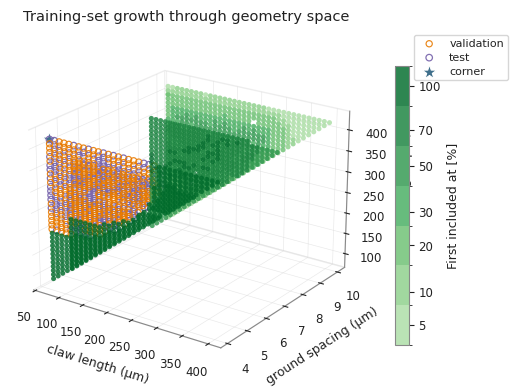

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


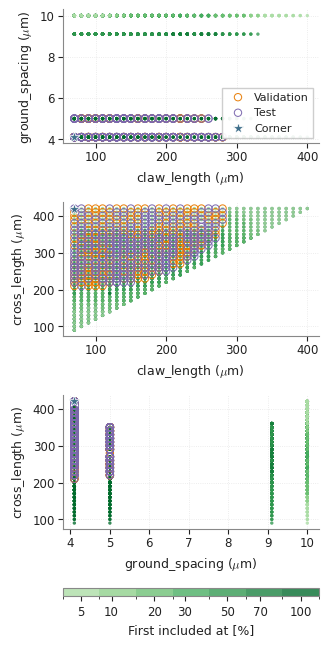

In [16]:
def plot_progression_green_shades_3d(save: bool = True) -> None:
    levels, cmap, norm = progression_colormap()
    train_entry = entry_percent_global[train_pool_idx]

    with plt.rc_context(paper_style):
        fig = plt.figure(figsize=(5.2, 4.15))
        ax = fig.add_subplot(111, projection="3d")
        sc = ax.scatter(
            geom_raw_um[train_pool_idx, 0],
            geom_raw_um[train_pool_idx, 1],
            geom_raw_um[train_pool_idx, 2],
            s=13,
            c=train_entry,
            cmap=cmap,
            norm=norm,
            alpha=0.82,
            linewidths=0,
            depthshade=False,
        )
        ax.scatter(geom_raw_um[val_idx, 0], geom_raw_um[val_idx, 1], geom_raw_um[val_idx, 2], s=20, facecolors="none", edgecolors=ORANGE, linewidths=0.85, alpha=0.9, label="validation", depthshade=False)
        ax.scatter(geom_raw_um[test_idx, 0], geom_raw_um[test_idx, 1], geom_raw_um[test_idx, 2], s=22, facecolors="none", edgecolors=PURPLE, linewidths=0.9, alpha=0.95, label="test", depthshade=False)
        ax.scatter([clipped_corner_um[0]], [clipped_corner_um[1]], [clipped_corner_um[2]], s=125, marker="*", c=BLUE, edgecolor="white", linewidth=0.8, label="corner", depthshade=False)

        style_3d_axis(ax)
        ax.set_title("Training-set growth through geometry space")
        ax.legend(loc="upper left", bbox_to_anchor=(1.13, 1.0), frameon=True, borderpad=0.35, labelspacing=0.35)
        cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.08)
        cbar.set_label("First included at [%]")
        cbar.set_ticks(levels)
        cbar.set_ticklabels([f"{level:.0f}" for level in levels])

        fig.tight_layout()
        if save:
            fig.savefig(PLOT_DIR / "geometry_3d_progression_green_shades.pdf", bbox_inches="tight")
            fig.savefig(PLOT_DIR / "geometry_3d_progression_green_shades.png", dpi=300, bbox_inches="tight")
        plt.show()


def plot_progression_green_shades_pairwise(save: bool = True) -> None:
    levels, cmap, norm = progression_colormap()
    train_entry = entry_percent_global[train_pool_idx]
    pairs = [
        (0, 1, "claw_length", "ground_spacing"),
        (0, 2, "claw_length", "cross_length"),
        (1, 2, "ground_spacing", "cross_length"),
    ]

    with plt.rc_context(paper_style):
        fig = plt.figure(figsize=(COLUMN_WIDTH_IN, 6.55))
        gs = gridspec.GridSpec(4, 1, height_ratios=[1.0, 1.0, 1.0, 0.055], hspace=0.58, figure=fig)
        axes = np.array([fig.add_subplot(gs[idx, 0]) for idx in range(3)])
        cax = fig.add_subplot(gs[3, 0])

        sc = None
        for ax, (i, j, xlabel, ylabel) in zip(axes, pairs):
            ax.set_axisbelow(True)
            sc = ax.scatter(
                geom_raw_um[train_pool_idx, i],
                geom_raw_um[train_pool_idx, j],
                s=6,
                c=train_entry,
                cmap=cmap,
                norm=norm,
                alpha=0.78,
                linewidths=0,
                rasterized=True,
                zorder=1,
            )
            ax.scatter(
                geom_raw_um[val_idx, i],
                geom_raw_um[val_idx, j],
                s=28,
                facecolors="none",
                edgecolors=ORANGE,
                linewidths=0.75,
                alpha=0.92,
                label="Validation",
                zorder=3,
            )
            ax.scatter(
                geom_raw_um[test_idx, i],
                geom_raw_um[test_idx, j],
                s=28,
                facecolors="none",
                edgecolors=PURPLE,
                linewidths=0.75,
                alpha=0.95,
                label="Test",
                zorder=3,
            )
            ax.scatter(
                [clipped_corner_um[i]],
                [clipped_corner_um[j]],
                s=70,
                marker="*",
                c=BLUE,
                edgecolor="white",
                linewidth=0.55,
                label="Corner",
                zorder=4,
            )
            ax.set_xlabel(fr"{xlabel} ($\mu$m)")
            ax.set_ylabel(fr"{ylabel} ($\mu$m)")
            ax.grid(axis="both", linestyle=":", color=GRID if "GRID" in globals() else "#D7D7D7")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.ticklabel_format(axis="both", style="plain")
            ax.tick_params(axis="both", pad=2)

        axes[0].legend(
            loc="lower right",
            frameon=True,
            fancybox=False,
            edgecolor="#CCCCCC",
            facecolor="white",
            framealpha=0.95,
            handletextpad=0.45,
            borderpad=0.4,
        )

        cbar = fig.colorbar(sc, cax=cax, orientation="horizontal")
        cbar.set_label("First included at [%]")
        cbar.set_ticks(levels)
        cbar.set_ticklabels([f"{level:.0f}" for level in levels])
        cbar.outline.set_edgecolor("#888888")
        cbar.outline.set_linewidth(0.8)

        fig.subplots_adjust(left=0.2, right=0.965, bottom=0.09, top=0.985)
        if save:
            fig.savefig(PLOT_DIR / "geometry_pairwise_progression_green_shades.pdf", bbox_inches="tight", pad_inches=0.04)
            fig.savefig(PLOT_DIR / "geometry_pairwise_progression_green_shades.png", bbox_inches="tight", pad_inches=0.04, dpi=300)
        plt.show()


plot_progression_green_shades_3d()
plot_progression_green_shades_pairwise()
